# Лабораторная работа №1: Решение нелинейных уравнений
## Студент: Сергиенко Александр Сергеевич
### Группы: ФИТ-231

### Вариант: 22. 10cos(x)−0.1x^2=0

## Подключение библиотек и определение функции

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Определение функции и её производных согласно варианту 22
# Уравнение: 10*cos(x) - 0.1*x^2 = 0

def f(x):
    return 10 * np.cos(x) - 0.1 * x**2

def df(x):
    # Первая производная: -10*sin(x) - 0.2*x
    return -10 * np.sin(x) - 0.2 * x

def ddf(x):
    # Вторая производная: -10*cos(x) - 0.2
    return -10 * np.cos(x) - 0.2

print("Функции определены.")

Функции определены.


## *Задание 1.* Отделение корней (Графический способ)

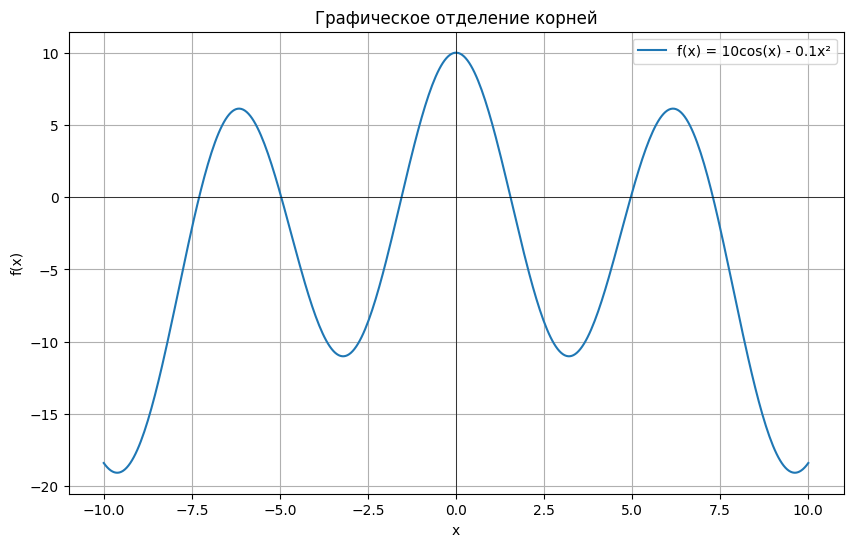

Анализ графика:
Видим пересечения с осью OX в районе x ≈ 1.5 и x ≈ 7.3.
Также есть симметричные корни x ≈ -1.5 и x ≈ -7.3.
Примечание: на графике также заметен корень вблизи x ≈ 5.0, но он менее очевиден при грубом просмотре.
Для решения выберем первые два положительных корня.


In [26]:
# Построение графика для отделения корней
x = np.linspace(-10, 10, 400)
y = f(x)

plt.figure(figsize=(10, 6))
plt.plot(x, y, label='f(x) = 10cos(x) - 0.1x²')
plt.axhline(0, color='black', linewidth=0.5) # Ось X
plt.axvline(0, color='black', linewidth=0.5) # Ось Y
plt.title("Графическое отделение корней")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.legend()
plt.show()

# Анализ графика
print("Анализ графика:")
print("Видим пересечения с осью OX в районе x ≈ 1.5 и x ≈ 7.3.")
print("Также есть симметричные корни x ≈ -1.5 и x ≈ -7.3.")
print("Примечание: на графике также заметен корень вблизи x ≈ 5.0, но он менее очевиден при грубом просмотре.")
print("Для решения выберем первые два положительных корня.")

## *Задание 1.* Аналитическое подтверждение

In [27]:
# Проверка перемены знака на выделенных интервалах
# Интервалы уточнены для корней 1.55 и 7.3
intervals = [(-1.6, -1.5), (1.5, 1.6), (-7.5, -7.0), (7.0, 7.5)]

print("Аналитическое отделение корней (проверка f(a)*f(b) < 0):")
valid_intervals = []
for a, b in intervals:
    fa = f(a)
    fb = f(b)
    sign_check = fa * fb < 0
    
    # Проверка монотонности (для уверенности в единственности корня)
    x_check = np.linspace(a, b, 10)
    df_vals = df(x_check)
    monotonic_check = np.all(df_vals > 0) or np.all(df_vals < 0)
    
    status = "Корень есть" if sign_check else "Нет смены знака"
    if sign_check and monotonic_check:
        status += ", единственный"
        valid_intervals.append((a, b))
        
    print(f"Интервал [{a}, {b}]: f(a)={fa:.3f}, f(b)={fb:.3f} -> {status}")

Аналитическое отделение корней (проверка f(a)*f(b) < 0):
Интервал [-1.6, -1.5]: f(a)=-0.548, f(b)=0.482 -> Корень есть, единственный
Интервал [1.5, 1.6]: f(a)=0.482, f(b)=-0.548 -> Корень есть, единственный
Интервал [-7.5, -7.0]: f(a)=-2.159, f(b)=2.639 -> Корень есть, единственный
Интервал [7.0, 7.5]: f(a)=2.639, f(b)=-2.159 -> Корень есть, единственный


## *Задание 2.* Реализация методов уточнения корней

In [ ]:
# 1. Метод дихотомии (деления пополам)
def dichotomy_method(a, b, eps): # Функция принимает границы отрезка и точность
    iterations = 0
    if f(a) * f(b) > 0:
        return None, 0, "На концах отрезка одинаковые знаки"
    
    while (b - a) / 2 > eps: # Условие остановки: половина отрезка меньше epsilon
        c = (a + b) / 2
        iterations += 1
        if f(c) == 0:
            return c, iterations, "Корень найден точно"
        elif f(a) * f(c) < 0:
            b = c
        else:
            a = c
    x_final = (a + b) / 2
    return x_final, iterations, "Успех"

# 2. Метод простой итерации (Исправленный)
def simple_iteration_method(x0, eps, a, b):
    iterations = 0
    x_prev = x0
    
    # Автоматический выбор лямбда для сходимости
    # phi(x) = x - lambda * f(x)
    # phi'(x) = 1 - lambda * f'(x)
    # Для сходимости нужно |phi'(x)| < 1.
    # Возьмем lambda = 1 / f'(x0), тогда phi'(x0) будет близко к 0.
    derivative = df(x0)
    if derivative == 0:
        # Если попали в экстремум, сдвинемся немного
        derivative = df(x0 + 0.1)
        
    lam = 1.0 / derivative
    
    # Проверка условия сходимости на конце отрезка
    # Если производная меняет знак сильно, лямбда может не подойти, 
    # но для данной функции f'(x) монотонна на выбранных отрезках.
    # Для надежности можно взять lambda с запасом: lam = 2 / (df(a) + df(b))
    
    print(f"  [Метод итерации] Выбрана lambda = {lam:.4f} (на основе f'({x0:.2f})={derivative:.2f})")

    while True:
        iterations += 1
        x_next = x_prev - lam * f(x_prev)  # Итерационная формула
        
        # Защита от зацикливания
        if iterations > 1000:
            return x_prev, iterations, "Превышен лимит итераций"
            
        # Проверка критерия сходимости
        if abs(x_next - x_prev) < eps:
            return x_next, iterations, "Успех"
        
        # Дополнительная проверка: не вылетели ли мы из интервала изоляции
        if not (a <= x_next <= b):
             print(f"  Предупреждение: итерация вышла за пределы интервала [{a},{b}]. x={x_next}")
             # Это может быть нормально, если корень на границе, но лучше вернуть ошибку или скорректировать
             
        x_prev = x_next

# 3. Метод Ньютона (касательных)
def newton_method(x0, eps, a, b):
    iterations = 0
    x_prev = x0
    
    # Проверка начального приближения: f(x0)*f''(x0) > 0
    # f''(x) отрицательна на наших интервалах (-1.5... и 7...)
    # Значит нужно f(x0) < 0.
    
    if f(x0) * ddf(x0) <= 0: 
        # Пробуем выбрать другой конец
        alt_x0 = a if x0 == b else b
        if f(alt_x0) * ddf(alt_x0) > 0: 
            x_prev = alt_x0
            print(f"  [Метод Ньютона] x0 изменен на {x_prev:.2f} (выполнение условия сходимости)")
        else:
            print(f"  [Метод Ньютона] Предупреждение: условие f(x0)*f''(x0) > 0 может не выполняться, x0={x_prev:.2f}")
    
    while True:
        iterations += 1
        derivative = df(x_prev)
        if derivative == 0:
            return x_prev, iterations, "Ошибка: производная равна нулю"
            
        x_next = x_prev - f(x_prev) / derivative
        
        if abs(x_next - x_prev) < eps: 
            return x_next, iterations, "Успех"
        x_prev = x_next
        if iterations > 1000:
            return x_prev, iterations, "Превышен лимит итераций"

# 4. Метод хорд
def chord_method(a, b, eps):
    iterations = 0
    # Выбор неподвижного конца: тот, где f(x)*f''(x) > 0
    # f''(x) < 0 на наших интервалах. Значит, неподвижен конец, где f(x) < 0.
    
    if f(a) * ddf(a) > 0: # Условие для выбора неподвижного конца
        x_fixed = a
        x_moving = b
    else:                 # Если оба конца не подходят, можно выбрать любой, но это может замедлить сходимость
        x_fixed = b
        x_moving = a
        
    x_prev = x_moving
    
    while True:
        iterations += 1
        # Формула метода хорд
        # x_next = x_prev - (f(x_prev) * (x_prev - x_fixed)) / (f(x_prev) - f(x_fixed))
        # Эквивалентная форма, чтобы не терять точность при больших числах:
        x_next = x_prev - f(x_prev) * (x_prev - x_fixed) / (f(x_prev) - f(x_fixed))

        if abs(x_next - x_prev) < eps:
            return x_next, iterations, "Успех"
        x_prev = x_next
        if iterations > 1000:
            return x_prev, iterations, "Превышен лимит итераций"

# 5. Метод Чебышева - расширение метода Ньютона с использованием второй производной для ускорения сходимости
def chebyshev_method(x0, eps, a, b):
    iterations = 0
    x_prev = x0
    # Аналогично Ньютону, лучше брать точку, где f*f'' > 0
    if f(x0) * ddf(x0) <= 0: # Условие для выбора начального приближения
         alt_x0 = a if x0 == b else b
         if f(alt_x0) * ddf(alt_x0) > 0: # Если другой конец подходит, используем его
             x_prev = alt_x0

    while True:
        iterations += 1 
        fx = f(x_prev) 
        dfx = df(x_prev)
        ddfx = ddf(x_prev)
        
        if dfx == 0: 
            return x_prev, iterations, "Ошибка: производная равна нулю"
            
        # Формула Чебышева
        delta = fx / dfx 
        x_next = x_prev - delta - (ddfx * delta**2) / (2 * dfx) 
        
        if abs(x_next - x_prev) < eps:
            return x_next, iterations, "Успех"
        x_prev = x_next
        if iterations > 1000:
            return x_prev, iterations, "Превышен лимит итераций"

print("Методы уточнения определены.")

Методы уточнения определены.


## Выполнение расчетов и вывод результатов

In [29]:
# Параметры задачи
epsilon = 1e-5 # Точность

# Интервалы (берем положительные корни)
intervals_to_solve = [
    {"name": "Корень 1", "a": 1.5, "b": 1.6},
    {"name": "Корень 2", "a": 7.0, "b": 7.5}
]

results = []

for item in intervals_to_solve:
    name = item["name"]
    a = item["a"]
    b = item["b"]
    
    # Начальные приближения
    # Для Ньютона и Чебышева: выбираем конец, где f(x) и f''(x) одного знака
    # f'' < 0 везде на этих отрезках.
    # Значит ищем точку, где f(x) < 0.
    if f(a) < 0:
        x0_newton = a
        x0_cheb = a
    else:
        x0_newton = b
        x0_cheb = b
        
    x0_iter = (a + b) / 2
    
    print(f"--- Расчет для {name} на интервале [{a}, {b}] ---")
    
    # Вызов методов
    res_dich, iter_d, msg_d = dichotomy_method(a, b, epsilon)
    res_iter, iter_i, msg_i = simple_iteration_method(x0_iter, epsilon, a, b)
    res_newton, iter_n, msg_n = newton_method(x0_newton, epsilon, a, b)
    res_chord, iter_c, msg_c = chord_method(a, b, epsilon)
    res_cheb, iter_ch, msg_ch = chebyshev_method(x0_cheb, epsilon, a, b)
    
    results.append({
        "Root": name,
        "Dichotomy": (res_dich, iter_d),
        "Iteration": (res_iter, iter_i),
        "Newton": (res_newton, iter_n),
        "Chord": (res_chord, iter_c),
        "Chebyshev": (res_cheb, iter_ch)
    })
    print("\n")

# Красивый вывод таблицы
print("-" * 95)
print(f"{'Метод':<15} | {'Корень 1 (x≈1.55)':<25} | {'Итер.':<6} | {'Корень 2 (x≈7.29)':<25} | {'Итер.':<6}")
print("-" * 95)

methods_keys = ["Dichotomy", "Iteration", "Newton", "Chord", "Chebyshev"]
method_names = ["Дихотомия", "Прост. итерация", "Ньютон", "Хорды", "Чебышев"]

for i, key in enumerate(methods_keys):
    r1 = results[0][key]
    r2 = results[1][key]
    print(f"{method_names[i]:<15} | {r1[0]:<25.8f} | {r1[1]:<6} | {r2[0]:<25.8f} | {r2[1]:<6}")

print("-" * 95)
print(f"Точность epsilon = {epsilon}")

--- Расчет для Корень 1 на интервале [1.5, 1.6] ---
  [Метод итерации] Выбрана lambda = -0.0970 (на основе f'(1.55)=-10.31)
  [Метод Ньютона] Предупреждение: условие f(x0)*f''(x0) > 0 может не выполняться, x0=1.60


--- Расчет для Корень 2 на интервале [7.0, 7.5] ---
  [Метод итерации] Выбрана lambda = -0.1033 (на основе f'(7.25)=-9.68)


-----------------------------------------------------------------------------------------------
Метод           | Корень 1 (x≈1.55)         | Итер.  | Корень 2 (x≈7.29)         | Итер. 
-----------------------------------------------------------------------------------------------
Дихотомия       | 1.54686890                | 13     | 7.29314423                | 15    
Прост. итерация | 1.54686610                | 2      | 7.29314017                | 4     
Ньютон          | 1.54686610                | 3      | 7.29314018                | 4     
Хорды           | 1.54686610                | 3      | 7.29314008                | 5     
Чебышев         |

## *Задание 3.* Проверка корректности нахождения корня

In [30]:
print("Проверка корректности (подстановка в уравнение f(x) ≈ 0):\n")
for res in results:
    print(f"--- {res['Root']} ---")
    for method in methods_keys:
        x_val, _ = res[method]
        val = f(x_val)
        print(f"{method:15}: x = {x_val:.8f}, f(x) = {val:.2e}")
    print()

Проверка корректности (подстановка в уравнение f(x) ≈ 0):

--- Корень 1 ---
Dichotomy      : x = 1.54686890, f(x) = -2.89e-05
Iteration      : x = 1.54686610, f(x) = -2.65e-10
Newton         : x = 1.54686610, f(x) = 5.27e-16
Chord          : x = 1.54686610, f(x) = 2.38e-10
Chebyshev      : x = 1.54686610, f(x) = 5.27e-16

--- Корень 2 ---
Dichotomy      : x = 7.29314423, f(x) = -4.02e-05
Iteration      : x = 7.29314017, f(x) = 9.06e-08
Newton         : x = 7.29314018, f(x) = 4.44e-15
Chord          : x = 7.29314008, f(x) = 1.03e-06
Chebyshev      : x = 7.29314018, f(x) = 4.44e-15

